In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
import textstat  

In [2]:
train_data = pd.read_csv("data/train.csv")
test_data = pd.read_csv("data/test.csv")

In [3]:
eda_train = train_data

In [4]:
eda_train["Doc Length"] = eda_train["TEXT"].apply(len)

In [5]:
stats = eda_train.groupby("LABEL")["Doc Length"].agg(
    Min_Length="min",
    Max_Length="max",
    Avg_Length="mean"
).reset_index()

In [6]:
stats["Author"] = stats["LABEL"].map({0: "Author 1", 1: "Author 2"})
stats = stats[["Author", "Min_Length", "Max_Length", "Avg_Length"]]

In [7]:
stats

,Author,Min_Length,Max_Length,Avg_Length
0,Author 1,237,5491,1047.709237
1,Author 2,164,3988,1047.615169


In [8]:
 eda_train.groupby("LABEL").size()

LABEL
0    1245
1     356
dtype: int64

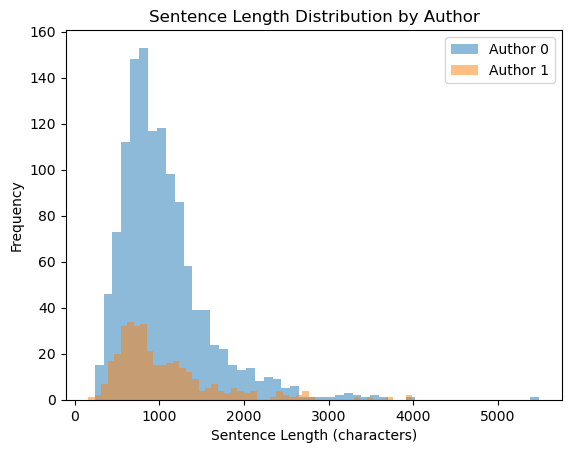

In [9]:
for label, group in eda_train.groupby("LABEL"):
    plt.hist(group["Doc Length"], bins=50, alpha=0.5, label=f"Author {label}")

plt.xlabel("Sentence Length (characters)")
plt.ylabel("Frequency")
plt.title("Sentence Length Distribution by Author")
plt.legend()
plt.show()

In [10]:
eda_train

,ID,TEXT,LABEL,Doc Length
0,0,When his speaker remained silent Dirrul assume...,0,892
1,1,If she had only come to me and said she desire...,0,759
2,2,He took a step to a little mound of good grass...,0,1108
3,3,The light of the torch flared more brightly. P...,0,1120
4,4,"""It's platinum,"" Carstairs said. Tim Carstairs...",0,738
...,...,...,...,...
1596,1596,Kinton realized to his surprise that the effor...,0,1379
1597,1597,Really it is very nice of you to come to the t...,0,963
1598,1598,"It lay there on the tray, its honed edge glitt...",0,729
1599,1599,She looked out the window and stretched. Sordm...,1,701


In [11]:
eda_train['word_count'] = eda_train['TEXT'].apply(lambda x: len(x.split()))
eda_train['char_count'] = eda_train['TEXT'].apply(len)

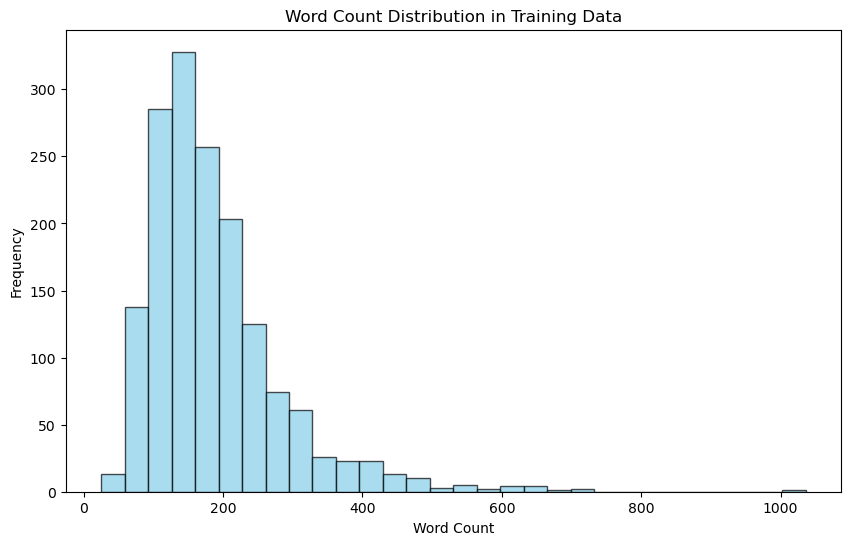

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(eda_train['word_count'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Word Count Distribution in Training Data')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

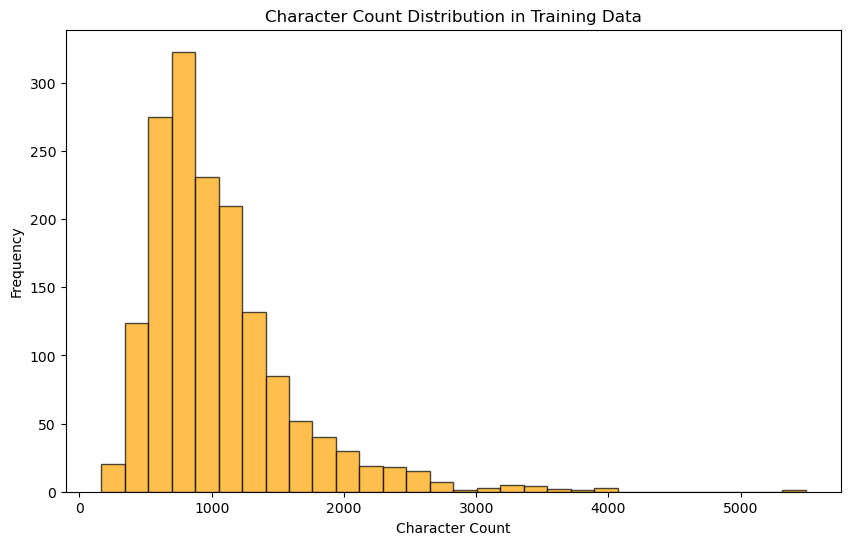

In [13]:
plt.figure(figsize=(10, 6))
plt.hist(eda_train['char_count'], bins=30, alpha=0.7, color='orange', edgecolor='black')
plt.title('Character Count Distribution in Training Data')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.show()

In [14]:
eda_train

,ID,TEXT,LABEL,Doc Length,word_count,char_count
0,0,When his speaker remained silent Dirrul assume...,0,892,156,892
1,1,If she had only come to me and said she desire...,0,759,144,759
2,2,He took a step to a little mound of good grass...,0,1108,186,1108
3,3,The light of the torch flared more brightly. P...,0,1120,186,1120
4,4,"""It's platinum,"" Carstairs said. Tim Carstairs...",0,738,131,738
...,...,...,...,...,...,...
1596,1596,Kinton realized to his surprise that the effor...,0,1379,250,1379
1597,1597,Really it is very nice of you to come to the t...,0,963,176,963
1598,1598,"It lay there on the tray, its honed edge glitt...",0,729,130,729
1599,1599,She looked out the window and stretched. Sordm...,1,701,138,701


In [15]:
X = train_data['TEXT']
y = train_data['LABEL']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [17]:
X_train = X_train.astype(str)
X_test = X_test.astype(str)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [18]:
class_weights = compute_class_weight(class_weight='balanced',classes=np.unique(y_train),y=y_train)
class_weights_dict = {label: weight for label, weight in zip(np.unique(y_train), class_weights)}
print(class_weights_dict)

{0: 0.6432160804020101, 1: 2.245614035087719}


In [19]:
def extract_stylometry_features(texts):
    features = []
    for text in texts:
        cleaned_text = re.sub(r'\s+', ' ', text)
        words = re.findall(r'\w+', cleaned_text)
        sentences = re.split(r'[.!?]', cleaned_text)
        
        avg_word_length = np.mean([len(word) for word in words]) if words else 0
        avg_sentence_length = np.mean([len(re.findall(r'\w+', sent)) for sent in sentences if sent]) if sentences else 0
        num_unique_words = len(set(words))
        num_total_words = len(words)
        lexical_diversity = num_unique_words / num_total_words if num_total_words > 0 else 0
        punctuation_count = len(re.findall(r'[,.!?]', cleaned_text))
        readability_score = textstat.flesch_reading_ease(cleaned_text)

        features.append([
            avg_word_length,
            avg_sentence_length,
            lexical_diversity,
            punctuation_count,
            readability_score
        ])
    return np.array(features)

In [20]:
X_train_stylo = extract_stylometry_features(X_train)
X_test_stylo = extract_stylometry_features(X_test)

In [21]:
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train).toarray()
X_test_tfidf = tfidf_vectorizer.transform(X_test).toarray()

In [22]:
X_train_combined = np.hstack([X_train_tfidf, X_train_stylo])
X_test_combined = np.hstack([X_test_tfidf, X_test_stylo])

In [23]:
model = Sequential([
    Input(shape=(X_train_combined.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [24]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [25]:
train = model.fit(
    X_train_combined,
    y_train,
    epochs=10,
    batch_size=32,
    class_weight=class_weights_dict,
    validation_data=(X_test_combined, y_test),
    verbose=1
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5154 - loss: 0.7772 - val_accuracy: 0.2212 - val_loss: 0.8251
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4646 - loss: 0.7088 - val_accuracy: 0.2212 - val_loss: 0.7409
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4813 - loss: 0.6769 - val_accuracy: 0.2212 - val_loss: 0.7460
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4858 - loss: 0.6753 - val_accuracy: 0.2212 - val_loss: 0.7887
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4764 - loss: 0.6906 - val_accuracy: 0.6262 - val_loss: 0.6836
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6692 - loss: 0.6268 - val_accuracy: 0.7477 - val_loss: 0.5755
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6910 - loss: 0.6205 - val_accuracy: 0.5732 - val_loss: 0.6972
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7735 - loss: 0.5302 - val_accuracy: 0.5171 - v

In [26]:
y_pred_prob = model.predict(X_test_combined).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.77      0.78       250
           1       0.24      0.25      0.25        71

    accuracy                           0.66       321
   macro avg       0.51      0.51      0.51       321
weighted avg       0.66      0.66      0.66       321



In [27]:
test_text = test_data['TEXT'].astype(str)

In [28]:
test_stylo_features = extract_stylometry_features(test_text)
test_tfidf_features = tfidf_vectorizer.transform(test_text).toarray()
test_combined_features = np.hstack([test_tfidf_features, test_stylo_features])

In [29]:
test_predictions = model.predict(test_combined_features).flatten()
predicted_labels = (test_predictions > 0.5).astype(int)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [30]:
test_data['LABEL'] = predicted_labels
output_path = "ouput/submission.csv"
test_data[['ID', 'LABEL']].to_csv(output_path, index=False)